# Variational Auto-Encoder (VAE) Implementation

### 0. pip

In [ ]:
# you should run this only once - uncomment before first use
%pip install pandas numpy matplotlib scikit-learn joblib tqdm
# if you want to use gpu, ensure you have cuda setup
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import joblib
import os
from tqdm import tqdm

In [2]:
normal_data_file = 'checkpointing/normal_data_preprocessed.joblib'
attack_data_file = 'checkpointing/attack_data_preprocessed.joblib'
normal_csv_path = r'data\LMD-2023 [2.3M Elements - Normal]checked.csv'
eors_csv_path = r'data\LMD-2023 [2.3M Elements - EORS]checked.csv'
eoht_csv_path = r'data\LMD-2023 [2.3M Elements - EOHT]checked.csv'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Using device: NVIDIA GeForce RTX 4070 SUPER


### 2. Data Loading & Preprocessing

In [3]:
# Check if checkpoint files exist
if os.path.exists(normal_data_file) and os.path.exists(attack_data_file):
    print("Checkpoint files found. Loading preprocessed data...")
    X_normal_preprocessed = joblib.load(normal_data_file)
    X_attack_preprocessed = joblib.load(attack_data_file)
    print("Data loaded successfully from checkpoints.")
else:
    print("Checkpoint files not found. Running full preprocessing pipeline...")
    # Load normal and attack datasets
    try:
        df_normal = pd.read_csv(normal_csv_path)
        df_attack_eors = pd.read_csv(eors_csv_path)
        df_attack_eoht = pd.read_csv(eoht_csv_path)
        df_attack = pd.concat([df_attack_eors, df_attack_eoht], ignore_index=True)
        print(f"Loaded {len(df_normal)} normal records and {len(df_attack)} attack records")
    except FileNotFoundError:
        print("Error: one of the dataset files not found. Please check the data folder.")

    # Feature selection as per Table 2 in the paper
    selected_features = [
        'Computer', 'DestinationPortName', 'EventID', 'EventRecordID',
        'Execution_ProcessID', 'Initiated', 'ProcessId', 'SourceIsIpv6',
        'SystemTime'
    ]

    # Process normal data
    df_normal['SystemTime'] = pd.to_datetime(df_normal['SystemTime'])
    df_normal['SystemTime_year'] = df_normal['SystemTime'].dt.year
    df_normal['SystemTime_month'] = df_normal['SystemTime'].dt.month
    df_normal['SystemTime_week'] = df_normal['SystemTime'].dt.isocalendar().week
    df_normal['SystemTime_day'] = df_normal['SystemTime'].dt.day
    df_normal['SystemTime_hour'] = df_normal['SystemTime'].dt.hour
    df_normal['SystemTime_minute'] = df_normal['SystemTime'].dt.minute
    df_normal['SystemTime_day_of_week'] = df_normal['SystemTime'].dt.dayofweek
    
    # Process attack data
    df_attack['SystemTime'] = pd.to_datetime(df_attack['SystemTime'])
    df_attack['SystemTime_year'] = df_attack['SystemTime'].dt.year
    df_attack['SystemTime_month'] = df_attack['SystemTime'].dt.month
    df_attack['SystemTime_week'] = df_attack['SystemTime'].dt.isocalendar().week
    df_attack['SystemTime_day'] = df_attack['SystemTime'].dt.day
    df_attack['SystemTime_hour'] = df_attack['SystemTime'].dt.hour
    df_attack['SystemTime_minute'] = df_attack['SystemTime'].dt.minute
    df_attack['SystemTime_day_of_week'] = df_attack['SystemTime'].dt.dayofweek
    
    time_features = ['SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute', 'SystemTime_day_of_week']
    final_features = selected_features[:-1] + time_features
    
    # Select features for both datasets
    X_normal = df_normal[final_features]
    X_attack = df_attack[final_features]

    # Define feature types
    categorical_features = ['Computer', 'DestinationPortName', 'EventID', 'Initiated', 'SourceIsIpv6', 'SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day_of_week']
    numerical_features = ['EventRecordID', 'Execution_ProcessID', 'ProcessId', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute']
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    # Fit preprocessor on normal data and transform both datasets
    X_normal_preprocessed = preprocessor.fit_transform(X_normal)
    X_attack_preprocessed = preprocessor.transform(X_attack)
    
    # Save the processed data
    print("Saving processed data to disk...")
    joblib.dump(X_normal_preprocessed, normal_data_file)
    joblib.dump(X_attack_preprocessed, attack_data_file)
    print("Checkpoint files saved successfully.")

# Split normal data into train and test sets
X_train, X_test = train_test_split(
    X_normal_preprocessed, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Attack data size: {X_attack_preprocessed.shape[0]}")

Checkpoint files found. Loading preprocessed data...
Data loaded successfully from checkpoints.
Training set size: 1306322
Test set size: 326581
Attack data size: 511105


### 3. Variational Auto-Encoder Architecture

In [12]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=10, architecture='simple'):
        super(VariationalAutoencoder, self).__init__()
        
        self.latent_dim = latent_dim
        self.architecture = architecture
        
        if architecture == 'simple':
            # Original 2-layer encoder
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 50),
                nn.BatchNorm1d(50),
                nn.ReLU(inplace=True),
                nn.Linear(50, 30),
                nn.BatchNorm1d(30),
                nn.ReLU(inplace=True)
            )
            encoder_output_dim = 30
            
            # Decoder
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, 30),
                nn.BatchNorm1d(30),
                nn.ReLU(inplace=True),
                nn.Linear(30, 50),
                nn.BatchNorm1d(50),
                nn.ReLU(inplace=True),
                nn.Linear(50, input_dim),
                nn.Sigmoid()
            )
        
        elif architecture == 'deep':
            # Deeper encoder (matching Stacked AE structure)
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 50),
                nn.BatchNorm1d(50),
                nn.ReLU(inplace=True),
                nn.Linear(50, 30),
                nn.BatchNorm1d(30),
                nn.ReLU(inplace=True),
                nn.Linear(30, 20),
                nn.BatchNorm1d(20),
                nn.ReLU(inplace=True)
            )
            encoder_output_dim = 20
            
            # Decoder
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, 20),
                nn.BatchNorm1d(20),
                nn.ReLU(inplace=True),
                nn.Linear(20, 30),
                nn.BatchNorm1d(30),
                nn.ReLU(inplace=True),
                nn.Linear(30, 50),
                nn.BatchNorm1d(50),
                nn.ReLU(inplace=True),
                nn.Linear(50, input_dim),
                nn.Sigmoid()
            )
        
        # Latent space layers
        self.fc_mu = nn.Linear(encoder_output_dim, latent_dim)
        self.fc_logvar = nn.Linear(encoder_output_dim, latent_dim)
        
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = μ + σ ⊙ ε, where ε ~ N(0,I)"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Get input dimension from preprocessed data
input_dim = X_train.shape[1]
model = VariationalAutoencoder(input_dim, latent_dim=10, architecture='deep')
print(f"Using {model.architecture} architecture:")
print(model)

Using deep architecture:
VariationalAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=71, out_features=50, bias=True)
    (1): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=50, out_features=30, bias=True)
    (4): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=30, out_features=20, bias=True)
    (7): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=20, bias=True)
    (1): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=20, out_features=30, bias=True)
    (4): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Lin

### 4. Training

In [13]:
# VAE Loss Function
def vae_loss(recon_x, x, mu, logvar):
    """
    VAE loss = Reconstruction loss + KL divergence
    Uses BCE for reconstruction loss as data is in [0,1] range
    """
    # Reconstruction loss (BCE - better for [0,1] normalized data)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    # KL divergence loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_loss

# Use only training data for training the VAE
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32).to(device)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)

# Training configuration
batch_size = 50
epochs = 20
learning_rate = 1e-3
weight_decay = 1e-5

# Checkpoint management
checkpoint_dir = "checkpointing"
model_checkpoint = f"{checkpoint_dir}/vae_checkpoint.pth"

# Check for existing checkpoint
start_epoch = 0
if os.path.exists(model_checkpoint):
    print("Loading checkpoint...")
    checkpoint = torch.load(model_checkpoint)
    model.load_state_dict(checkpoint['model_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"Resuming from epoch {start_epoch}")
else:
    print("No checkpoint found. Starting from epoch 0.")

# Move model to device
model = model.to(device)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Load optimizer state if checkpoint exists
if os.path.exists(model_checkpoint):
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Training loop
for epoch in tqdm(range(start_epoch, epochs), desc="Training Epochs"):
    running_loss = 0.0
    
    for batch_idx, data in enumerate(train_loader):
        inputs, _ = data
        inputs = inputs.to(device)

        # Forward pass
        recon_batch, mu, logvar = model(inputs)
        loss = vae_loss(recon_batch, inputs, mu, logvar)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        # Print progress every 1000 batches
        if (batch_idx + 1) % 1000 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    avg_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}')
    
    # Save checkpoint
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
        'architecture': model.architecture
    }, model_checkpoint)
    print(f"Checkpoint saved at epoch {epoch+1}")

# Save final model
torch.save(model, "checkpointing/final_vae_model.pth")
print("Training completed. Final model saved.")

No checkpoint found. Starting from epoch 0.


Training Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch [1/20], Batch [1000/26127], Loss: 696.3197
Epoch [1/20], Batch [2000/26127], Loss: 574.3488
Epoch [1/20], Batch [2000/26127], Loss: 574.3488
Epoch [1/20], Batch [3000/26127], Loss: 570.1927
Epoch [1/20], Batch [3000/26127], Loss: 570.1927
Epoch [1/20], Batch [4000/26127], Loss: 529.4241
Epoch [1/20], Batch [4000/26127], Loss: 529.4241
Epoch [1/20], Batch [5000/26127], Loss: 506.4538
Epoch [1/20], Batch [5000/26127], Loss: 506.4538
Epoch [1/20], Batch [6000/26127], Loss: 487.5886
Epoch [1/20], Batch [6000/26127], Loss: 487.5886
Epoch [1/20], Batch [7000/26127], Loss: 527.5942
Epoch [1/20], Batch [7000/26127], Loss: 527.5942
Epoch [1/20], Batch [8000/26127], Loss: 503.3773
Epoch [1/20], Batch [8000/26127], Loss: 503.3773
Epoch [1/20], Batch [9000/26127], Loss: 491.4337
Epoch [1/20], Batch [9000/26127], Loss: 491.4337
Epoch [1/20], Batch [10000/26127], Loss: 504.5586
Epoch [1/20], Batch [10000/26127], Loss: 504.5586
Epoch [1/20], Batch [11000/26127], Loss: 496.7585
Epoch [1/20], Bat

Training Epochs:   5%|▌         | 1/20 [01:29<28:15, 89.23s/it]

Epoch [1/20], Average Loss: 516.0845
Checkpoint saved at epoch 1
Epoch [2/20], Batch [1000/26127], Loss: 432.8276
Epoch [2/20], Batch [1000/26127], Loss: 432.8276
Epoch [2/20], Batch [2000/26127], Loss: 466.2651
Epoch [2/20], Batch [2000/26127], Loss: 466.2651
Epoch [2/20], Batch [3000/26127], Loss: 424.6477
Epoch [2/20], Batch [3000/26127], Loss: 424.6477
Epoch [2/20], Batch [4000/26127], Loss: 450.6302
Epoch [2/20], Batch [4000/26127], Loss: 450.6302
Epoch [2/20], Batch [5000/26127], Loss: 442.5133
Epoch [2/20], Batch [5000/26127], Loss: 442.5133
Epoch [2/20], Batch [6000/26127], Loss: 499.1338
Epoch [2/20], Batch [6000/26127], Loss: 499.1338
Epoch [2/20], Batch [7000/26127], Loss: 440.2781
Epoch [2/20], Batch [7000/26127], Loss: 440.2781
Epoch [2/20], Batch [8000/26127], Loss: 462.2573
Epoch [2/20], Batch [8000/26127], Loss: 462.2573
Epoch [2/20], Batch [9000/26127], Loss: 430.9279
Epoch [2/20], Batch [9000/26127], Loss: 430.9279
Epoch [2/20], Batch [10000/26127], Loss: 441.6538
Epo

...

Epoch [18/20], Average Loss: 431.6742
Checkpoint saved at epoch 18
Epoch [19/20], Batch [1000/26127], Loss: 430.4909
Epoch [19/20], Batch [1000/26127], Loss: 430.4909
Epoch [19/20], Batch [2000/26127], Loss: 425.8889
Epoch [19/20], Batch [2000/26127], Loss: 425.8889
Epoch [19/20], Batch [3000/26127], Loss: 431.7269
Epoch [19/20], Batch [3000/26127], Loss: 431.7269
Epoch [19/20], Batch [4000/26127], Loss: 434.4536
Epoch [19/20], Batch [4000/26127], Loss: 434.4536
Epoch [19/20], Batch [5000/26127], Loss: 412.5391
Epoch [19/20], Batch [5000/26127], Loss: 412.5391
Epoch [19/20], Batch [6000/26127], Loss: 431.6003
Epoch [19/20], Batch [6000/26127], Loss: 431.6003
Epoch [19/20], Batch [7000/26127], Loss: 446.8725
Epoch [19/20], Batch [7000/26127], Loss: 446.8725
Epoch [19/20], Batch [8000/26127], Loss: 392.7926
Epoch [19/20], Batch [8000/26127], Loss: 392.7926
Epoch [19/20], Batch [9000/26127], Loss: 441.7779
Epoch [19/20], Batch [9000/26127], Loss: 441.7779
Epoch [19/20], Batch [10000/26127

Training Epochs:  95%|█████████▌| 19/20 [38:39<02:22, 142.66s/it]

Epoch [19/20], Average Loss: 431.2545
Checkpoint saved at epoch 19
Epoch [20/20], Batch [1000/26127], Loss: 409.4594
Epoch [20/20], Batch [1000/26127], Loss: 409.4594
Epoch [20/20], Batch [2000/26127], Loss: 440.7208
Epoch [20/20], Batch [2000/26127], Loss: 440.7208
Epoch [20/20], Batch [3000/26127], Loss: 415.5438
Epoch [20/20], Batch [3000/26127], Loss: 415.5438
Epoch [20/20], Batch [4000/26127], Loss: 446.7155
Epoch [20/20], Batch [4000/26127], Loss: 446.7155
Epoch [20/20], Batch [5000/26127], Loss: 440.4131
Epoch [20/20], Batch [5000/26127], Loss: 440.4131
Epoch [20/20], Batch [6000/26127], Loss: 412.5341
Epoch [20/20], Batch [6000/26127], Loss: 412.5341
Epoch [20/20], Batch [7000/26127], Loss: 449.0244
Epoch [20/20], Batch [7000/26127], Loss: 449.0244
Epoch [20/20], Batch [8000/26127], Loss: 454.2466
Epoch [20/20], Batch [8000/26127], Loss: 454.2466
Epoch [20/20], Batch [9000/26127], Loss: 417.5493
Epoch [20/20], Batch [9000/26127], Loss: 417.5493
Epoch [20/20], Batch [10000/26127

Training Epochs: 100%|██████████| 20/20 [41:01<00:00, 123.09s/it]

Epoch [20/20], Average Loss: 431.0866
Checkpoint saved at epoch 20
Training completed. Final model saved.


### 5. Evaluation

In [14]:
# Load the model
loaded_model = torch.load("checkpointing/final_vae_model.pth", weights_only=False).to(device)
model = loaded_model 

# Convert test and attack data to tensors
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32).to(device)
X_attack_tensor = torch.tensor(X_attack_preprocessed.toarray(), dtype=torch.float32).to(device)

# MSE-only evaluation for fair comparison with Stacked AE
def calculate_mse_losses_batched(model, data_tensor, batch_size=1000):
    """Calculate MSE reconstruction loss for each sample (for evaluation only)"""
    model.eval()
    all_losses = []
    
    with torch.no_grad():
        for i in range(0, len(data_tensor), batch_size):
            batch = data_tensor[i:i+batch_size]
            recon_batch, _, _ = model(batch)
            
            # Calculate per-sample MSE losses (for comparison with Stacked AE)
            mse_loss = F.mse_loss(recon_batch, batch, reduction='none').mean(dim=1)
            all_losses.extend(mse_loss.cpu().numpy())
    
    return np.array(all_losses)

# Calculate MSE losses for evaluation
print("Calculating MSE reconstruction losses for test data...")
test_errors = calculate_mse_losses_batched(model, X_test_tensor)

print("Calculating MSE reconstruction losses for attack data...")
attack_errors = calculate_mse_losses_batched(model, X_attack_tensor)

print(f"\nAverage MSE reconstruction error for test normal data: {np.mean(test_errors):.4f}")
print(f"Average MSE reconstruction error for attack data: {np.mean(attack_errors):.4f}")

# Use 99th percentile threshold (matching Stacked AE)
threshold = np.percentile(test_errors, 99)
print(f"Threshold for anomaly detection (99th percentile): {threshold:.4f}")

# Evaluate on attack data
predictions_attack = (attack_errors > threshold)
accuracy_attack = np.sum(predictions_attack) / len(attack_errors)
print(f"Anomalies correctly detected in attack data: {np.sum(predictions_attack)} / {len(attack_errors)} ({accuracy_attack:.2%})")

# Evaluate on test normal data
predictions_test = (test_errors > threshold)
false_positive_rate = np.sum(predictions_test) / len(test_errors) 
print(f"False positives in test normal data: {np.sum(predictions_test)} / {len(test_errors)} ({false_positive_rate:.2%})")

Calculating MSE reconstruction losses for test data...
Calculating MSE reconstruction losses for attack data...
Calculating MSE reconstruction losses for attack data...

Average MSE reconstruction error for test normal data: 0.0060
Average MSE reconstruction error for attack data: 0.0753
Threshold for anomaly detection (99th percentile): 0.0400
Anomalies correctly detected in attack data: 480806 / 511105 (94.07%)
False positives in test normal data: 3266 / 326581 (1.00%)

Average MSE reconstruction error for test normal data: 0.0060
Average MSE reconstruction error for attack data: 0.0753
Threshold for anomaly detection (99th percentile): 0.0400
Anomalies correctly detected in attack data: 480806 / 511105 (94.07%)
False positives in test normal data: 3266 / 326581 (1.00%)


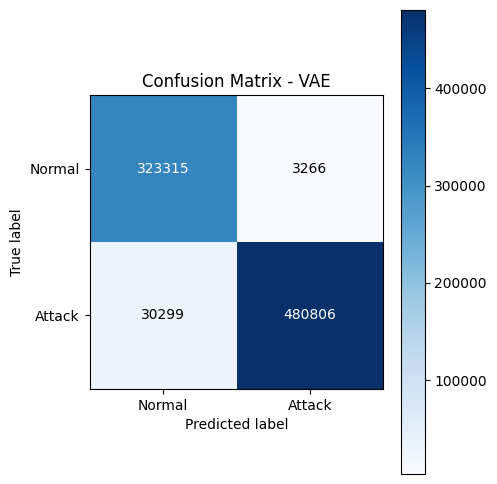

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# true labels: 0 for normal, 1 for attack
y_true = np.concatenate([
    np.zeros(len(predictions_test), dtype=int),
    np.ones(len(predictions_attack), dtype=int)
])
# predicted labels: cast booleans to int
y_pred = np.concatenate([
    predictions_test.astype(int),
    predictions_attack.astype(int)
])

# compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# plot
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
ax.figure.colorbar(im, ax=ax)
classes = ['Normal', 'Attack']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix - VAE')

# annotate counts
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()